# SatoshiDice analysis review

# Analisi delle transazioni SatoshiDice

La seguente relazione analizzera’ i dati di transazioni bitcoin per
ricavare informazioni sulle scommesse effettuate dagli utenti
utilizzando il servizo di betting on-chain SatoshiDice.

# Prima parte: analisi dei dati forniti

Prima di iniziare a effettuare le analisi sui dati grezzi forniti
effettuo degli step di preprocessing per migliorare le performance e
controllare che i dati siano coerenti con il funzionamento di una
normale blockchain.

## Preprocessing

I file `.csv` (e `.tsv`) verranno letti da `data_loader.py` (il codice
seguente) per poi essere trasformati in file `.parquet`, un formato
efficente per salvare dataframe pandas sul disco. Questi saranno i file
che verranno importati da ogni script per l’analisi.

In [1]:
import pandas

pandas.set_option('display.max_columns', None)
pandas.set_option('display.width', None)
pandas.set_option('display.max_colwidth', None)

def read_dataset(name, columns):
    return pandas.read_csv(f"./data/raw/{name}", header=None, engine='pyarrow', names=columns)

def save_parquet(dataframe: pandas.DataFrame, name):
    return dataframe.to_parquet(f"./data/processed/{name}.parquet", index=False)

def read_parquet(name, columns=None):
    return pandas.read_parquet(f"./data/processed/{name}.parquet", columns=columns)

> **Warning**
>
> Sono pero’ presenti dei problemi nei file grezzi!

### Transazioni invalide

Eseguendo dei test per verificare le garanzie dei file (es. valori
nulli, righe invalide, format di `timestamp`) e’ risultato che siano
presenti degli id di transazione duplicati!

In [2]:
from src.data_loading.data_loader import read_dataset

transactions = read_dataset("transactions.csv", ["timestamp", "transaction_block_id", "transaction_id", "is_codebase", "transaction_fee"])

duplicated = transactions.duplicated(subset=["transaction_id"], keep=False)

invalid_transactions = transactions[duplicated].sort_values("transaction_id")

print(invalid_transactions)

         timestamp  transaction_block_id  transaction_id  is_codebase  \
142572  1289723848                 91722          142572            1   
142841  1289781379                 91880          142572            1   
142726  1289757588                 91812          142726            1   
142783  1289768691                 91842          142726            1   

        transaction_fee  
142572                0  
142841                0  
142726                0  
142783                0  

In particolare 2 coppie di transazioni hanno lo stesso `transaction_id`,
ma hanno diverso `timestamp` e `block_id`. Ipotizzo siano due
transazioni distinte a cui e’ stato assegnato lo stesso id, ma per
semplicita’ le escludo dalle analisi.

### Output invalidi

Anche in `outputs` abbiamo un problema simile ma per motivi diversi.

In [3]:
from src.data_loading.data_loader import read_dataset

outputs = read_dataset("outputs.csv", ["transaction_id", "output_position", "output_address_id", "amount", "script_type"])

duplicated = outputs.duplicated(subset=["transaction_id", "output_position"], keep=False)

invalid_outputs = outputs[duplicated].sort_values("transaction_id")

print(invalid_outputs)

        transaction_id  output_position  output_address_id      amount  \
172980          142572                0             141029  5000000000   
173305          142572                0             141029  5000000000   
173166          142726                0             141187  5000000000   
173237          142726                0             141187  5000000000   

        script_type  
172980            1  
173305            1  
173166            1  
173237            1  

Nel dataset sono presenti due coppie con identico `transaction_id` e
`output_position`. Questo significa che sono presenti nella stessa
transazione due `output_position` identici, combinazione che dovrebbe
essere univoca da protocollo bitcoin.

In questo caso pero’ le righe sono identiche sia per quanto riguarda
`output_address_id` sia per `amount` quindi ipotizzo siano semplicemente
duplicate. Anche in questo caso verranno escluse dall’analisi.

### Schema delle transazioni

Per facilitare il modello mentale con cui ho approcciato le transazioni
ho effettuato un merge preventivo di `inputs`, `outputs` e
`transactions`. Questo dataframe espanso e’ il modo in cui verranno
analizzate le transazioni per il resto dell’analisi, ogni riga
rappresenta una parte della transazione con input
(`input_transaction_id` e `input_transaction_position`), output
(`output_position`) e metadati della transazione (`amount`, `timestamp`
…).

In [4]:
import pandas
from src.data_loading.data_loader import read_dataset, save_parquet

inputs = read_dataset("inputs.csv", ["transaction_id", "input_transaction_id", "input_transaction_position"])

outputs = read_dataset("outputs.csv", ["transaction_id", "output_position", "output_address_id", "amount", "script_type"])
outputs = outputs.drop(columns=["script_type"])
invalid_outputs = outputs.duplicated(subset=["transaction_id", "output_position"], keep=False)
outputs = outputs[~invalid_outputs]

transactions = read_dataset("transactions.csv", ["timestamp", "transaction_block_id", "transaction_id", "is_codebase", "transaction_fee"])
transactions = transactions.drop(columns=["is_codebase"])
invalid_transactions = transactions.duplicated(subset=["transaction_id"], keep=False)
transactions = transactions[~invalid_transactions]
transactions["timestamp"] = pandas.to_datetime(transactions["timestamp"], unit="s")

complete_transactions = transactions.merge(inputs, how="left").merge(outputs, how="left")

mappings = read_dataset("mappings.csv", ["address_hash", "address_id"])
save_parquet(mappings, "mappings")

satoshi_dices = pandas.read_csv("./data/raw/satoshiDiceInfos.tsv", sep='\t')[["Name", "Address"]]
satoshi_dices.columns = ["name", "address_hash"]
satoshi_dices = satoshi_dices.merge(mappings)

complete_transactions["is_satoshi_bet"] = complete_transactions["output_address_id"].isin(satoshi_dices["address_id"])

save_parquet(complete_transactions, "transactions")
save_parquet(satoshi_dices, "satoshi_dices")

> **Tip**
>
> E’ stata inserita anche una nuova riga `is_satoshi_bet` che indica se
> la transazione e’ una scommessa

A questo punto il dataset e’ nel formato corretto per l’analisi e si
possono cominciare a estrarre informazioni.

## Analisi generali delle bet e dei payout

### Transazioni di scommessa rispetto al numero complessivo di transazioni

Calcolo la percentuale di transazioni di bet rispetto al numero
complessivo di transazioni. Sia in termini di percentuale, sia in
termini di numero assoluto di transazioni.

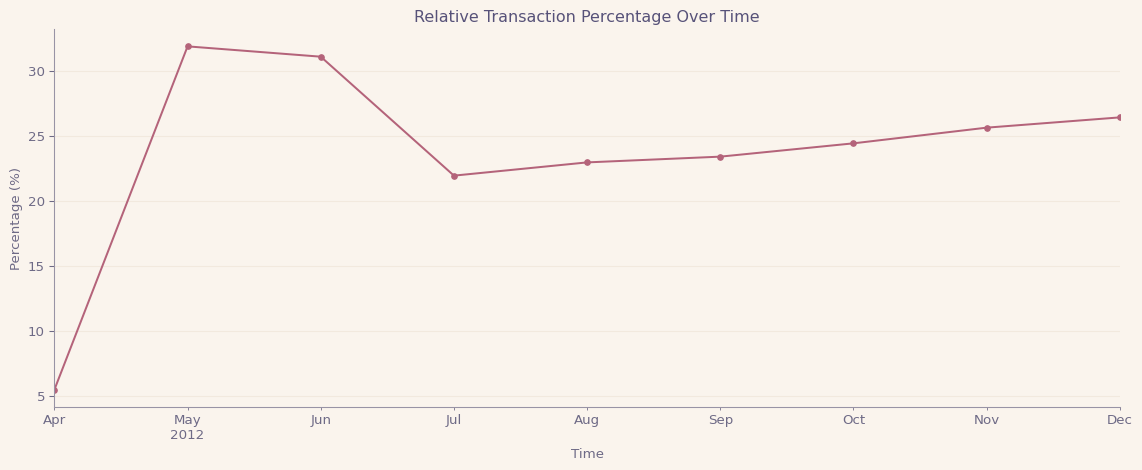

<Figure size 672x480 with 0 Axes>

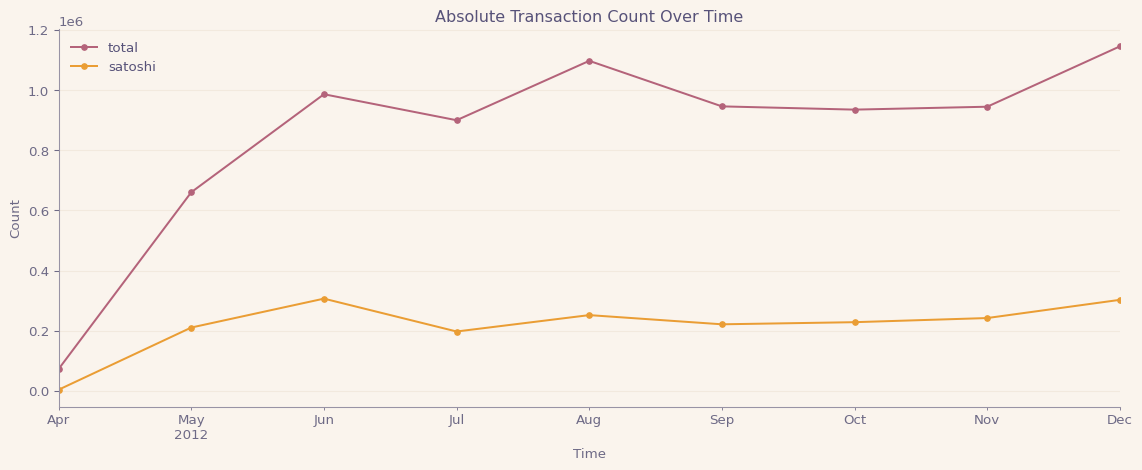

<Figure size 672x480 with 0 Axes>

In [5]:
import pandas
from src.plotting.plots import plot_absolute_transaction_percentage, plot_relative_transaction_percentage
from src.data_loading.data_loader import read_parquet

transactions = read_parquet("transactions", columns=["timestamp", "is_satoshi_bet", "amount", "transaction_id"])
satoshi_bets = transactions[transactions["is_satoshi_bet"]]

earliest_satoshi_bet_timestamp = satoshi_bets["timestamp"].min()

def resample(dataframe, start, time_step="1ME"):
    return dataframe[dataframe["timestamp"].between(start, "2023-12-31")].resample(time_step, on="timestamp")

def resampled_amount(dataframe, start):
    return resample(dataframe, start)["transaction_id"].nunique()

transactions_amount = resampled_amount(transactions, earliest_satoshi_bet_timestamp)
satoshi_bets_amount = resampled_amount(satoshi_bets, earliest_satoshi_bet_timestamp)

transactions_amount.name = None
satoshi_bets_amount.name = None

relative_amounts = (satoshi_bets_amount / transactions_amount * 100)

plot_relative_transaction_percentage(relative_amounts)

absolute_amounts = pandas.DataFrame({
    "total": transactions_amount,
    "satoshi": satoshi_bets_amount
})

plot_absolute_transaction_percentage(absolute_amounts)

> **Tip**
>
> La prima transazione verso il servizio SatoshiDice risale al 21 aprile
> 2012 mentre la prima transazione bitcoin risale al 3 gennaio 2009. Nel
> grafico viene mostrato solamente il periodo rilevante in cui e’
> presente almeno una scommessa.

## Popolarita’ di ogni indirizzo di betting

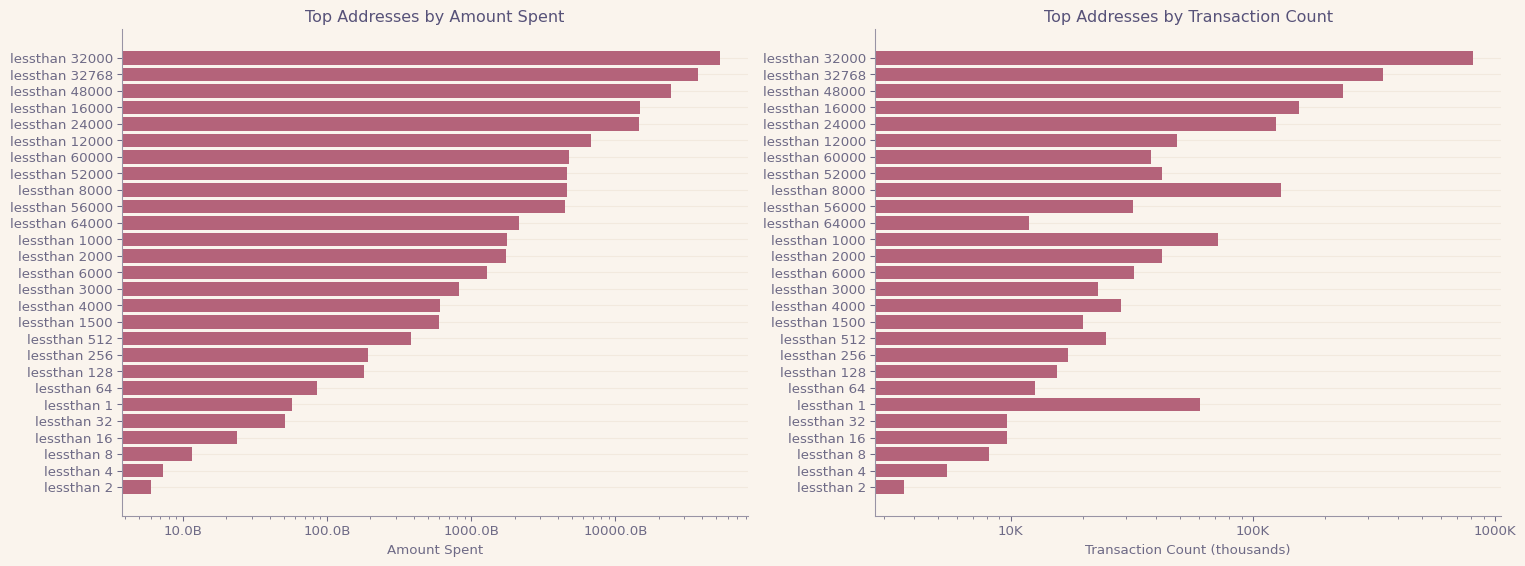

<Figure size 672x480 with 0 Axes>

In [6]:
from src.plotting.plots import plot_satoshi_dice_popularity
from src.data_loading.data_loader import read_parquet
from src.data_loading.satoshi_dices_info import name, address_hash

transactions = read_parquet("transactions", columns=["is_satoshi_bet", "amount", "transaction_id", "output_address_id", "output_position"])
satoshi_bets = transactions[transactions["is_satoshi_bet"]]

satoshi_outputs = satoshi_bets.drop_duplicates(subset=["transaction_id", "output_address_id", "output_position"])[["output_address_id", "amount"]]

satoshi_bets_amount = satoshi_outputs.groupby(["output_address_id"]).agg(
    amount=("amount", "sum"),
    count=("amount", "count")
).reset_index()

satoshi_bets_amount["name"] = satoshi_bets_amount["output_address_id"].apply(address_hash).apply(name)

(   
    satoshi_bets_amount
    .sort_values(by="amount", ascending=False)["output_address_id"]
    .to_csv("./data/processed/sorted_satoshi_dices.csv", index=False, header=False)
)

plot_satoshi_dice_popularity(satoshi_bets_amount)

Due servizi hanno risultati particolari rispetto agli altri:
`less than 64000` e `les than 1`. Che hanno rispettivamente la
probabilita’ di vincita piu’ alta e piu’ bassa.

Per `less than 64000` possiamo notare che l’ammontare speso non riflette
il numero di transazioni effettuate, cioe’ si tendono a fare meno
scommesse ma con somme piu’ alte. Questo e’ spiegato dal fatto che e’
molto probabile vincere quindi per guadagnare le persone tengono a
rischiare piu’ soldi perche’ sono piu’ sicure di guadagnare (nonostante
il valore atteso sia comunque negativo per ogni transazione).

Per `less than 1` notiamo l’opposto, ovvero le persone tendono a fare
piu’ bet ma piccole. Questo e’ spiegato dal fatto che le persone sono
quasi sicure di perdere per cui non investono troppi soldi in ogni
singola scommessa ma l’indirizzo e’ nettamente piu’ popolare in termini
di ammontare di transazioni.

E’ interessante il fatto che in termini di soldi spesi per le scommesse
`less than 64000` sia piu’ di 37 volte maggiore di `less than 1`
nonostante il valore atteso di `less than 1` sia migliore.

> **Tip**
>
> Il risultato dell’ordinamento degli indirizzi e’ stato salvato in un
> file `.csv` perche’ sara’ necessario successivamente

## Distanza tra scommessa e payout

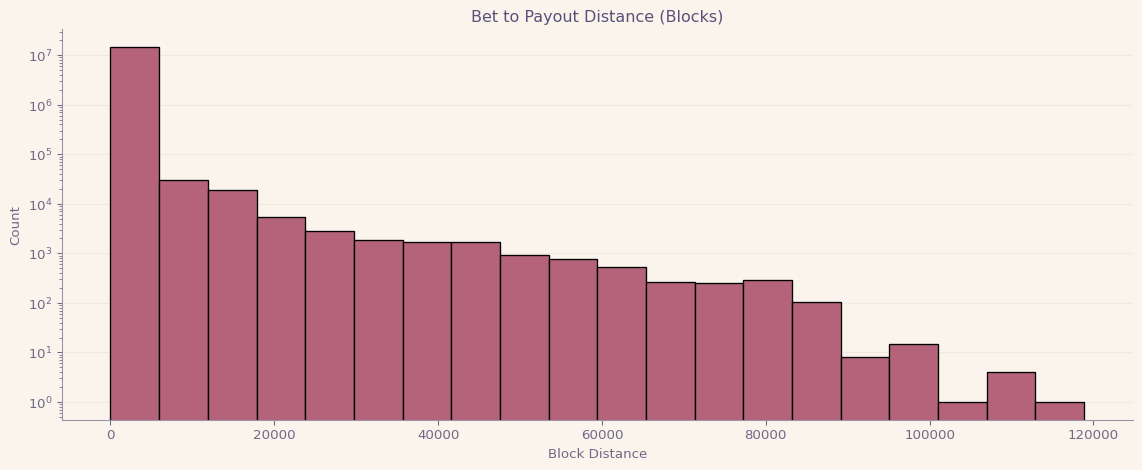

<Figure size 672x480 with 0 Axes>

In [7]:
from src.plotting.plots import plot_payout_distance_distribution
from src.data_loading.data_loader import read_parquet
import pandas

transactions = read_parquet("transactions", columns=["transaction_id", "transaction_block_id", "input_transaction_id", "is_satoshi_bet", "input_transaction_position", "output_position"])
# dropping transactions which don't have an input (which have not been spent yet)
transactions = transactions.dropna()

satoshi_payouts = pandas.merge(
    transactions[transactions["is_satoshi_bet"]],
    transactions,
    left_on=["input_transaction_id", "input_transaction_position"],
    right_on=["transaction_id", "output_position"]
)

block_delta = satoshi_payouts["transaction_block_id_x"] - satoshi_payouts["transaction_block_id_y"]

plot_payout_distance_distribution(block_delta)

> **Tip**
>
> Il 24% delle transazioni ha 0 blocchi di distanza

## Analisi sugli indirizzi di SatoshiDice piu’ popolari

I tre indirizzi piu’ popolari sono i seguenti

In [8]:
from src.data_loading.satoshi_dices_info import k_most_popular_dices, address_hash, name

popular_dices = [name(address_hash(dice)) for dice in k_most_popular_dices(3)]

print(popular_dices)

['lessthan 32000', 'lessthan 32768', 'lessthan 48000']

Indicati nei grafici come 1, 2 e 3

### Distribuzione temporale delle bet

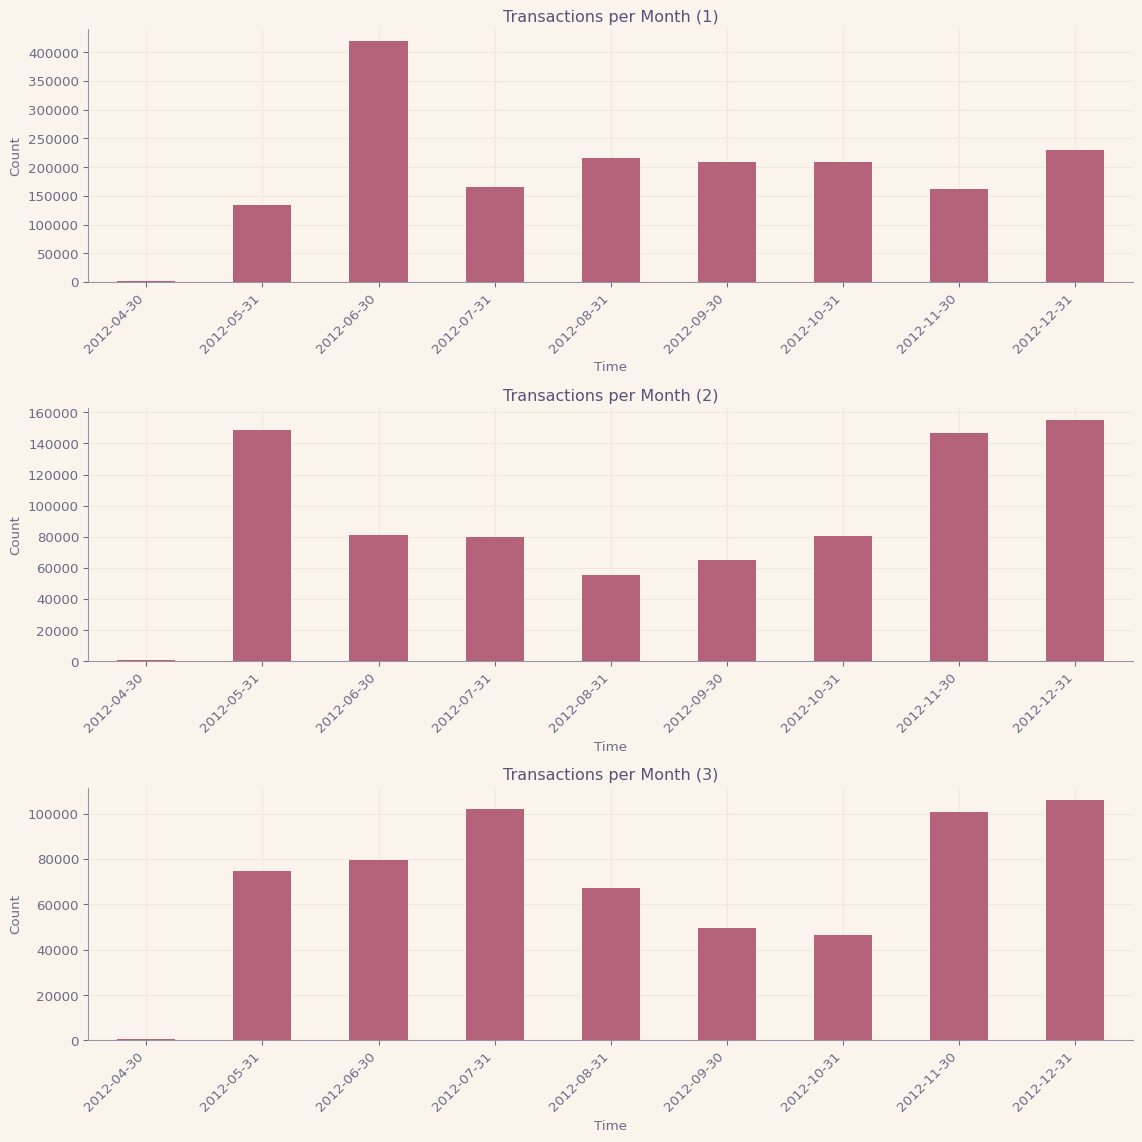

<Figure size 672x480 with 0 Axes>

In [9]:
import pandas
from src.data_loading.data_loader import read_parquet
from src.plotting.plots import plot_time_distribution
from src.plotting.plot_map_popular import plot_map_popular

transactions = read_parquet("transactions")
satoshi_bets = transactions[transactions["is_satoshi_bet"]]
satoshi_bets.drop_duplicates(subset="transaction_id")

def temporal_distribution(bets: pandas.DataFrame, time_step = "1ME"):
    return bets.resample(time_step, on="timestamp").size()

plot_map_popular(
    amount_popular_dices=3,
    bets_dataframe=satoshi_bets,
    map_function=temporal_distribution,
    plot_function=plot_time_distribution
)

### Correlazione tra somma scommessa e commissione

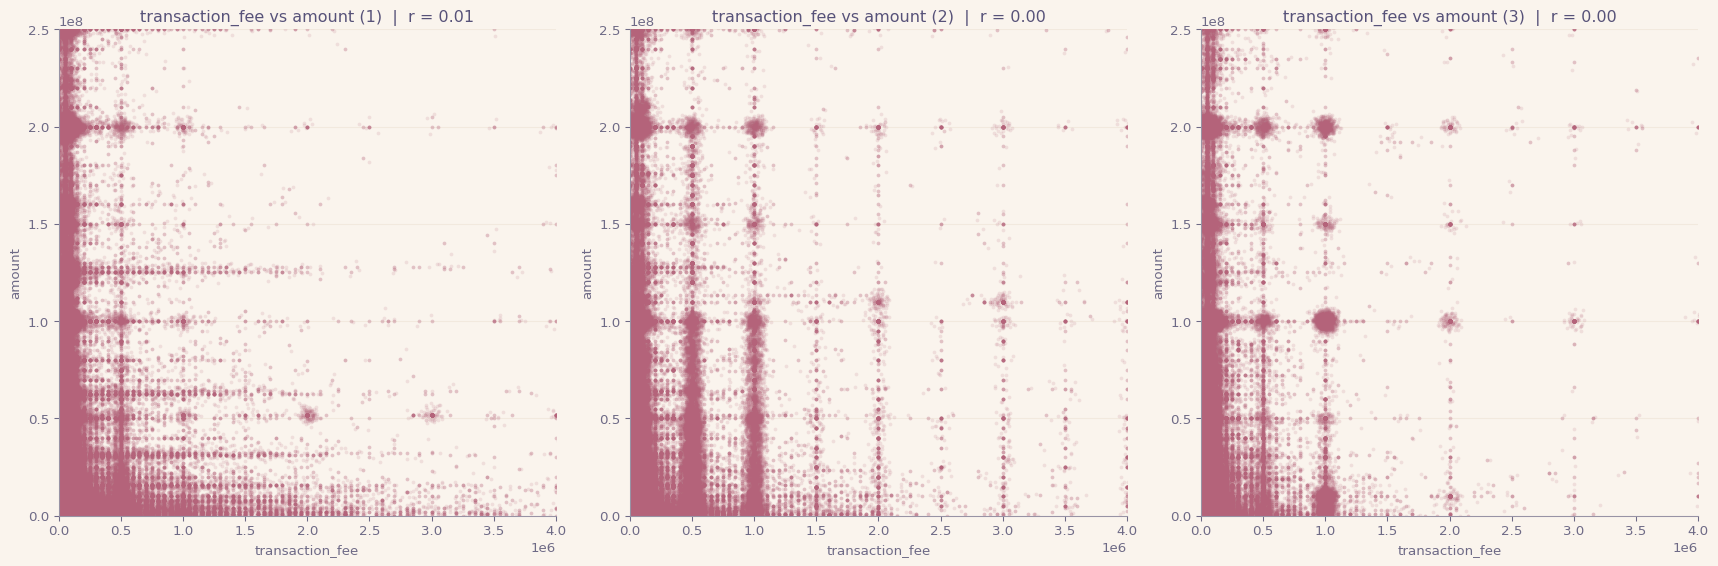

<Figure size 672x480 with 0 Axes>

In [10]:
from src.data_loading.data_loader import read_parquet
from src.plotting.plots import plot_bet_correlation
from src.plotting.plot_map_popular import plot_map_popular

transactions = read_parquet("transactions")
satoshi_bets = transactions[transactions["is_satoshi_bet"]]

satoshi_bets = satoshi_bets.drop_duplicates(subset=["transaction_id", "output_position"])

def identity(x):
    return x

plot_map_popular(
    amount_popular_dices=3,
    bets_dataframe=satoshi_bets,
    map_function=identity,
    plot_function=plot_bet_correlation
)

Dato che i valori di correlazione sono prossimi allo 0 possiamo dedurne
che non e’ presente una correlazione lineare. E’ possibile che sia
presente una correlazione di forma non lineare, tra i vari test di
correlazione effettuati non ho riscontrato nessun altra correlazione
(es. inversa o di rango).

Ipotizzo che sia improbabile che una correlazione tra somma scommessa e
commissione abbia una forma cosi’ complicata da non essere riscontrata
da queste ulteriori verifiche ma non posso affermare con certezza che
non ne esista una.

> **Tip**
>
> Sono presenti alcune linee verticali e orizzontali su cui si
> concentrano i punti, questi sono valori “interi” in cui tendono ad
> aggirarsi sia le quantita’ scommesse che i valori delle commissioni

### Intervalli tra bet consecutive

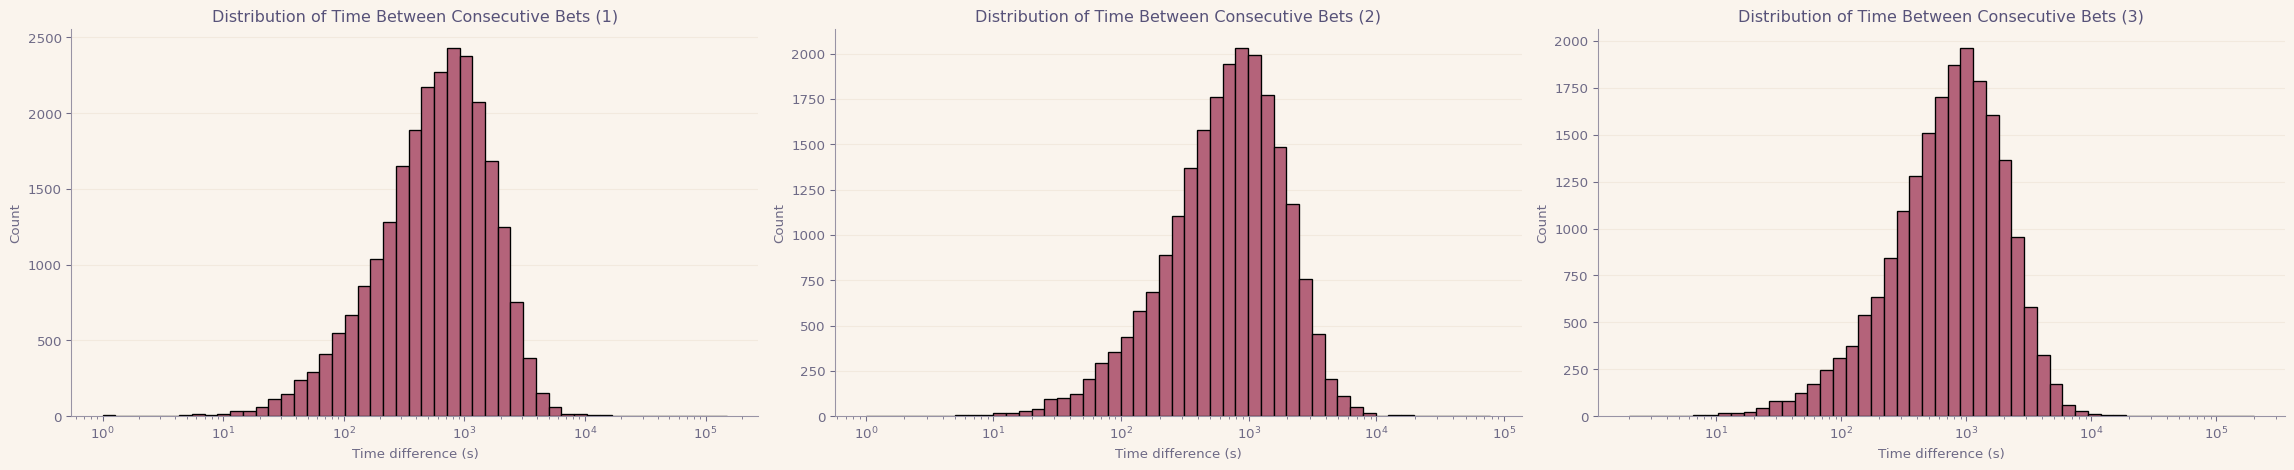

<Figure size 672x480 with 0 Axes>

In [11]:
import pandas
from src.data_loading.data_loader import read_parquet
from src.plotting.plots import plot_bet_distance
from src.plotting.plot_map_popular import plot_map_popular

transactions = read_parquet("transactions")
satoshi_bets = transactions[transactions["is_satoshi_bet"]]
satoshi_bets = satoshi_bets.drop_duplicates(subset="transaction_id")

def bet_distance(dataframe: pandas.DataFrame):
    return dataframe.sort_values("transaction_block_id")["timestamp"].diff().dt.total_seconds()

plot_map_popular(
    amount_popular_dices=3,
    bets_dataframe=satoshi_bets,
    map_function=bet_distance,
    plot_function=plot_bet_distance
)

# Seconda parte: analisi di sequenze di scommesse

## Descrizione del dominio del problema

Una catena di bet e’ definita come una sequenza di transazioni in cui
gli output di una sono l’input di un’altra, stabilendo quindi un legame
diretto e tracciabile tra le transazioni.

Per ottenere delle catene lineari e facilmente interpretabili mi limito
ad analizzare le `simple bet`.

Ovvero le transazioni della forma: - Un input - Un output a un indirizzo
satoshi dice - Un altro output di resto

Due simple bet appartengono alla stessa catena se l’input della seconda
coincide con l’output di resto della prima.

## Calcolo dei risultati

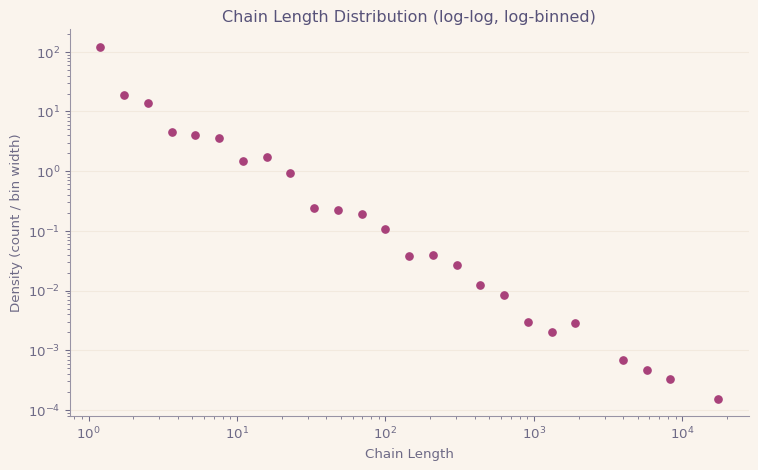

<Figure size 672x480 with 0 Axes>

In [12]:
import pandas
import networkx
from src.data_loading.satoshi_dices_info import k_most_popular_dices
from src.plotting.plots import plot_chain_length_distribution
from src.data_loading.data_loader import read_parquet
from src.analysis2.bet_chains_functions import simple_bets, transaction_connections, edges_attribute, save_to_csv

transactions = read_parquet(
    "transactions",
    columns=["transaction_id", "output_position", "input_transaction_id", "input_transaction_position", "output_address_id", "is_satoshi_bet"]
)

simple_bet_transactions = simple_bets(transactions)

simple_bet_connections = transaction_connections(simple_bet_transactions)

most_popular_dice_id = k_most_popular_dices(1)[0]
popular_simple_bets_connections = simple_bet_connections[simple_bet_connections["input_address"] == most_popular_dice_id]

G = networkx.from_pandas_edgelist(
    popular_simple_bets_connections,
    source="input_id",
    target="output_id",
    edge_attr=["output_address"],
    create_using=networkx.DiGraph,
)

paths_nodes = [edges_attribute(G, component, "output_address") for component in networkx.weakly_connected_components(G)]
paths_lengths = [len(nodes) for nodes in paths_nodes]

length_distribution = pandas.Series(paths_lengths).value_counts().sort_index()

save_to_csv('./data/processed/simple_bet_chain_nodes.csv', paths_nodes)
plot_chain_length_distribution(length_distribution)

> **Tip**
>
> La maggior parte del codice che gestisce le computazioni e’ nel file
> `bet_chains_functions`, lo snippet di codice qui sopra esprime in
> maniera chiara la pipeline di operazioni effettuate per trovare il
> risultato

E’ bene notare che il grafo ha una forma particolare. Per via del modo
in cui e’ definita una catena di simple bet ha effettivamente solamente
un input e un output rilevanti (dato che l’output verso satoshi dice non
e’ utile per definire la forma dei cammini). Per cui il grafico e’ un
insieme di cammini lineari e la libreria `networkx` fornisce una
funzione per trovare le componenti debolmente connesse, che nel nostro
caso calcola i cammini lineari.

> **Tip**
>
> Il grafico puo’ essere visto come una foresta di alberi degeneri o
> strutture simili a linked list

# Terza parte: appartenenza delle catene a un wallet

## Calcolo dei risultati

Nella sezione precedente sono stati trovati i nodi che appartengono ai
cammini lineari, ora verra’ effettuata un’operazione di
de-anonimizzazione (per quanto possibile) appoggiandosi al servizio
`Wallet Explorer` per verificare se le intere catene di transazioni sono
riconducibili a un singolo portafoglio.

In [13]:
from src.data_loading.address_to_wallet_mapping import get_wallet, load_cache, load_driver
import csv
from itertools import islice
import uuid
from collections import Counter
import pandas

def read_first_k_chains(filepath: str, k: int) -> list[list[str]]:
    with open(filepath, newline="", encoding="utf-8") as f:
        return list(islice(csv.reader(f), k))


cache = load_cache()
driver = load_driver()

bitcoin_address_chains = read_first_k_chains("./data/processed/simple_bet_chain_nodes.csv", 10)

wallet_address_chains = [[get_wallet(cache, driver, bitcoin_address) for bitcoin_address in chain] for chain in bitcoin_address_chains]

def summarize_chain(bitcoin_addresses: list[str], wallet_addresses: list[str]) -> dict:

    dominant_wallet_address, dominant_wallet_count = Counter(wallet_addresses).most_common(1)[0]

    return {
        "id": uuid.uuid4(),
        "chain_length": len(bitcoin_addresses),
        "unique_addresses": len(set(bitcoin_addresses)),
        "unique_wallets": len(set(wallet_addresses)),
        "dominant_wallet": dominant_wallet_address,
        "dominant_wallet_percentage": dominant_wallet_count / len(wallet_addresses) * 100,
    }

chains_data = [summarize_chain(bitcoin_addresses, wallet_addresses)
          for bitcoin_addresses, wallet_addresses in zip(bitcoin_address_chains, wallet_address_chains)]

chains_data = pandas.DataFrame(chains_data)

chains_data.to_csv("./outputs/deanonymized_chains.csv", index=None)

print(chains_data)

                                     id  chain_length  unique_addresses  \
0  652ea999-79de-4e0d-8908-3e8aa414a5df           716               716   
1  5ec3b4b1-08ef-487f-b120-44d54327bc2b           441               441   
2  1ea6d9f2-8a32-4132-aec9-4c3ef27e127b           351               351   
3  0b529ec0-8a5b-422b-a71d-bb4531c535b7           292               292   
4  ae424c42-fc2f-45db-b564-8d6039b6a3b0           272               272   
5  69193286-c43f-4858-b408-0d53740e6a9d           245               245   
6  b8684474-383e-4d44-b4e9-2776d35dc518           242               242   
7  baebd84a-1bbb-4acb-8487-ad0eee7bb4e5           234               234   
8  70348a00-d7b2-420d-b0d0-e6cabe40595f           232               232   
9  ed8a33c6-ef81-4a5e-b361-4547fc50c76e           228               228   

   unique_wallets dominant_wallet  dominant_wallet_percentage  
0              76    [0025d633f8]                   50.139665  
1               1    [00002c4379]             

> **Warning**
>
> Le informazioni per associare gli indirizzi ai portafogli sono
> estratte dal sito `WalletExplorer.com` tramite web scraping in quanto
> requisito del progetto, il sito in realta’ fornisce un’API pubblica
> che permette di fare richieste di informazioni sugli indirizzi in
> batch

Il codice utilizza la libreria `Selenium` per aprire un’istanza di un
browser che apre il sito e trova il nome del portafoglio associato
tramite selezione per nome di classe.

I risultati vengono poi salvati in un file di cache cosi’ che le
successive chiamate possano riutilizzarli.

> **Tip**
>
> Come identificatore per il risultato finale ho scelto di utilizzare
> degli `uuid` versione 4 per evitare di incorrere in problemi derivati
> dall’utilizzo di identificatori incrementali, come nel dataset
> iniziale del progetto

## Considerazioni sui risultati

La maggior parte delle lunghe catene appartiene a un singolo wallet (nel
caso della seconda piu’ lunga, tutta la catena). Questo conferma che le
catene sono composte perlopiu’ da un unico utente che continua a
scommettere i propri coin.